In [1]:
using DrWatson
@quickactivate "ProjectoSIR"

using DifferentialEquations
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using Statistics
using FFTW

"""
    Modelo de Lotka-Volterra (Presas-Predadores)

    Sistema de equações:
    dx/dt = α*x - β*x*y  # Variação da população de presas
    dy/dt = δ*x*y - γ*y   # Variação da população de predadores

    Onde:
    - x: população de presas (ex: lebres)
    - y: população de predadores (ex: raposas)
    - α: taxa de crescimento natural das presas (na ausência de predadores)
    - β: taxa de predação (eficiência dos predadores em capturar presas)
    - δ: taxa de conversão de presas em novos predadores
    - γ: taxa de mortalidade natural dos predadores (na ausência de presas)
"""
function lotka_volterra!(du, u, p, t)
    x, y = u
    α, β, δ, γ = p

    @inbounds begin
        du[1] = α*x - β*x*y  # equação para presas
        du[2] = δ*x*y - γ*y   # equação para predadores
    end
    nothing
end

Main.var"##278".lotka_volterra!

Parâmetros da modelo

In [2]:
p_lv = [
    0.1,   # α: taxa de reprodução das presas
    0.02,  # β: taxa de predação
    0.01,  # δ: eficiência de conversão (presas -> predadores)
    0.3    # γ: mortalidade dos predadores
]

4-element Vector{Float64}:
 0.1
 0.02
 0.01
 0.3

Condições iniciais: [presas, predadores]

In [3]:
u0_lv = [40.0, 9.0]

2-element Vector{Float64}:
 40.0
  9.0

Parâmetros de tempo

In [4]:
tspan_lv = (0.0, 200.0)  # tempo total de simulação
dt_lv = 0.01              # passo de integração

0.01

Criar e resolver o problema

In [5]:
prob_lv = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_lv)
sol_lv = solve(prob_lv,
               Tsit5(),              # método de 5ª ordem
               dt = dt_lv,
               reltol = 1e-8,         # tolerância relativa
               abstol = 1e-10,         # tolerância absoluta
               saveat = 0.1,           # salvar a cada 0.1 unidades de tempo
               dense = true)           # permitir interpolação

┌ Warning: Verbosity toggle: dense_output_saveat 
│  Dense output is incompatible with saveat. Please use the SavingCallback from the Callback Library to mix the two behaviors.
└ @ OrdinaryDiffEqCore ~/.julia/packages/OrdinaryDiffEqCore/q5Gdj/src/solve.jl:177


retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 2001-element Vector{Float64}:
   0.0
   0.1
   0.2
   0.3
   0.4
   0.5
   0.6
   0.7
   0.8
   0.9
   ⋮
 199.2
 199.3
 199.4
 199.5
 199.6
 199.7
 199.8
 199.9
 200.0
u: 2001-element Vector{Vector{Float64}}:
 [40.0, 9.0]
 [39.67773201890398, 9.088990237207573]
 [39.3511378950319, 9.1758827263069]
 [39.02053587808413, 9.260562174341601]
 [38.6862482028163, 9.342916311941519]
 [38.348600187590776, 9.422836265416295]
 [38.007919320048416, 9.500216918705295]
 [37.664534369324684, 9.574957250331227]
 [37.318774466549755, 9.646960666854303]
 [36.970968217675335, 9.71613530831863]
 ⋮
 [17.824353144929567, 5.50801931850314]
 [17.807442037033947, 5.441315154549741]
 [17.79290768632291, 5.375334300035647]
 [17.780718473177817, 5.310082577781689]
 [17.770843588537023, 5.245565084818681]
 [17.763253013148027, 5.181786245480113]
 [17.757917517460715, 5.118749811715716]
 [17.75480865796634, 5.056458873592463]
 [17.7538987

Preparar DataFrame com resultados

In [6]:
df_lv = DataFrame()
df_lv[!, :t] = sol_lv.t
df_lv[!, :prey] = [u[1] for u in sol_lv.u]      # presas
df_lv[!, :predator] = [u[2] for u in sol_lv.u]  # predadores

2001-element Vector{Float64}:
 9.0
 9.088990237207573
 9.1758827263069
 9.260562174341601
 9.342916311941519
 9.422836265416295
 9.500216918705295
 9.574957250331227
 9.646960666854303
 9.71613530831863
 ⋮
 5.50801931850314
 5.441315154549741
 5.375334300035647
 5.310082577781689
 5.245565084818681
 5.181786245480113
 5.118749811715716
 5.056458873592463
 4.994915937053484

Calcular derivadas para análise

In [7]:
df_lv[!, :dprey_dt] = p_lv[1] .* df_lv.prey .- p_lv[2] .* df_lv.prey .* df_lv.predator
df_lv[!, :dpredator_dt] = p_lv[3] .* df_lv.prey .* df_lv.predator .- p_lv[4] .* df_lv.predator

2001-element Vector{Float64}:
  0.9000000000000004
  0.8796081183812947
  0.8580494468233706
  0.8353523334487725
  0.8115489002366512
  0.7866749261309169
  0.7607697060795098
  0.733875889299783
  0.7060392940838303
  0.6773087043292239
  ⋮
 -0.6706369809299996
 -0.6634355041661331
 -0.6561720201740996
 -0.6488539394858811
 -0.6414883588875672
 -0.6340820722588977
 -0.6266415740250623
 -0.6191730642026372
 -0.6116824631058786

Calcular pontos de equilíbrio

In [8]:
x_star = p_lv[4] / p_lv[3]  # γ/δ - ponto de equilíbrio para presas
y_star = p_lv[1] / p_lv[2]  # α/β - ponto de equilíbrio para predadores

println("="^60)
println("Modelo de Lotka-Volterra (Presas-Predadores)")
println("="^60)
println("\nParâmetros da modelo:")
println("α (taxa de reprodução das presas) = ", p_lv[1])
println("β (taxa de predação) = ", p_lv[2])
println("δ (eficiência de conversão) = ", p_lv[3])
println("γ (mortalidade dos predadores) = ", p_lv[4])

println("\nCondições iniciais:")
println("Presas (x0) = ", u0_lv[1])
println("Predadores (y0) = ", u0_lv[2])

println("\nPontos de equilíbrio:")
println("x* = γ/δ = ", round(x_star, digits=3))
println("y* = α/β = ", round(y_star, digits=3))

Modelo de Lotka-Volterra (Presas-Predadores)

Parâmetros da modelo:
α (taxa de reprodução das presas) = 0.1
β (taxa de predação) = 0.02
δ (eficiência de conversão) = 0.01
γ (mortalidade dos predadores) = 0.3

Condições iniciais:
Presas (x0) = 40.0
Predadores (y0) = 9.0

Pontos de equilíbrio:
x* = γ/δ = 30.0
y* = α/β = 5.0


Gráfico 1: Dinâmica das populações

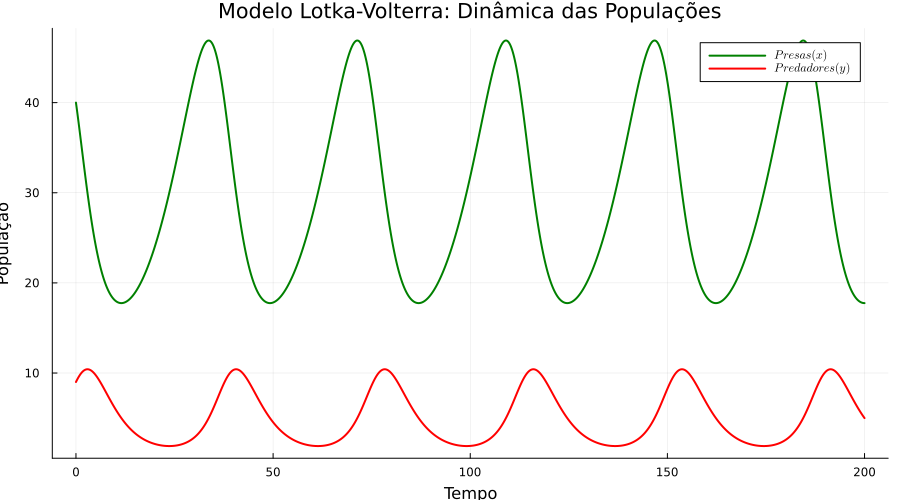

In [9]:
plt1 = plot(df_lv.t, [df_lv.prey df_lv.predator],
            label = [L"Presas (x)" L"Predadores (y)"],
            xlabel = "Tempo", ylabel = "População",
            title = "Modelo Lotka-Volterra: Dinâmica das Populações",
            linewidth = 2,
            legend = :topright,
            grid = true,
            size = (900, 500),
            color = [:green :red])

Adicionar linhas dos pontos de equilíbrio

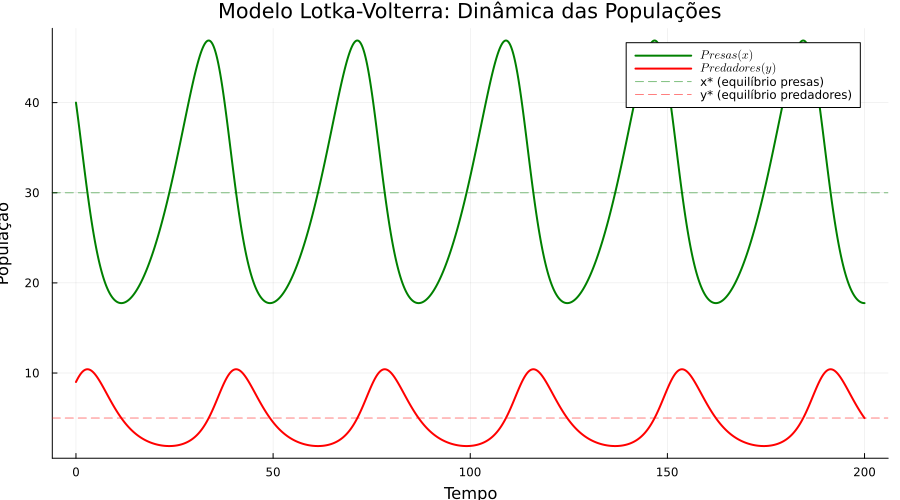

In [10]:
hline!(plt1, [x_star], color=:green, linestyle=:dash, alpha=0.5, label="x* (equilíbrio presas)")
hline!(plt1, [y_star], color=:red, linestyle=:dash, alpha=0.5, label="y* (equilíbrio predadores)")

Salvar gráfico

In [11]:
plots_dir = plotsdir()
if !isdir(plots_dir)
    mkpath(plots_dir)
end
savefig(plt1, joinpath(plots_dir, "lv_dynamics.png"))

println("\nGráfico salvo em: ", joinpath(plots_dir, "lv_dynamics.png"))
println("\nSimulação concluída com sucesso!")


Gráfico salvo em: /home/mabaptishta/work/2026-1--study--simulation-modeling/labs/lab02/ProjectoSIR/plots/lv_dynamics.png

Simulação concluída com sucesso!


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*